[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/USUARIO/REPO/blob/main/sesion-01/sesion-01-ciclo-vida-ml.ipynb)

# Sesión 01 — Ciclo de Vida de Proyectos de Machine Learning
**Curso:** Ingeniería del Conocimiento (ISO56B)  
**Docente:** Msc. Jaime Antonio Huaytalla Pariona  
**Periodo:** 2026-II | Universidad Nacional del Centro del Perú  

---

## Objetivo
Recorrer el ciclo de vida completo de un proyecto de Machine Learning — desde la recolección de datos hasta la evaluación y serialización del modelo — utilizando el dataset **Heart Disease** de UCI y las herramientas del ecosistema Scikit-learn.

## 1. Configuración del entorno
Instalamos/importamos las librerías necesarias. En Google Colab la mayoría ya están disponibles.

In [21]:
# Librerías principales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)
import joblib

# Configuración visual
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print('Entorno configurado correctamente.')

Entorno configurado correctamente.


---
## 2. Etapa 1 — Recolección de datos
Cargamos el **Heart Disease dataset** directamente desde el repositorio UCI Machine Learning a través de una URL pública.

| Variable | Descripción |
|---|---|
| `age` | Edad del paciente |
| `sex` | Sexo (1 = masculino, 0 = femenino) |
| `cp` | Tipo de dolor torácico (0-3) |
| `trestbps` | Presión arterial en reposo (mm Hg) |
| `chol` | Colesterol sérico (mg/dl) |
| `fbs` | Glucosa en ayunas > 120 mg/dl (1 = sí) |
| `restecg` | Resultados electrocardiográficos en reposo |
| `thalach` | Frecuencia cardíaca máxima alcanzada |
| `exang` | Angina inducida por ejercicio (1 = sí) |
| `oldpeak` | Depresión del ST inducida por ejercicio |
| `slope` | Pendiente del segmento ST |
| `ca` | Número de vasos coloreados por fluoroscopía |
| `thal` | Thalassemia (0-3) |
| `target` | Diagnóstico de enfermedad cardíaca (1 = presente, 0 = ausente) |

In [22]:
# Fuente pública: repositorio procesado de Heart Disease (Cleveland)
URL = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/heart.csv'

# Intentamos cargar desde la URL; si falla, usamos la copia local de Kaggle
try:
    df = pd.read_csv(URL)
    print(f'Dataset cargado desde URL — {df.shape[0]} registros, {df.shape[1]} columnas')
except Exception as e:
    print(f'Error al cargar desde URL: {e}')
    print('Intentando cargar desde OpenML como alternativa...')
    # Alternativa: descarga desde el repo de Kaggle vía sklearn
    from sklearn.datasets import fetch_openml
    import scipy.sparse
    try:
        # First, fetch the full bunch to get feature names (return_X_y=False)
        full_bunch = fetch_openml(data_id=1574, as_frame=False, return_X_y=False)
        feature_names = full_bunch.feature_names

        # Then, explicitly fetch X (features) and y (target) as arrays (return_X_y=True)
        X_openml, y_openml = fetch_openml(data_id=1574, as_frame=False, return_X_y=True)

        # Check if X is a sparse matrix and convert to dense if necessary
        if scipy.sparse.issparse(X_openml):
            X_openml = X_openml.toarray()

        # Create a DataFrame from the data and target arrays
        df = pd.DataFrame(data=X_openml, columns=feature_names)
        df['target'] = y_openml

        # Ensure target is numeric, as OpenML often returns it as object type
        df['target'] = pd.to_numeric(df['target'])

        print(f'Dataset cargado desde OpenML — {df.shape[0]} registros, {df.shape[1]} columnas')

        # ============================================
        # CORRECCIÓN: Renombrar columnas genéricas
        # ============================================
        # Si las columnas se llaman att_1, att_2, etc., las renombramos
        if df.columns[0].startswith('att_'):
            column_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
                           'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
            df.columns = column_names + ['target']
            print('✅ Columnas renombradas correctamente')

    except Exception as openml_e:
        print(f'Error al cargar desde OpenML: {openml_e}')
        print('No se pudo cargar el dataset desde ninguna fuente.')
        raise # Re-raise the exception if both methods fail

df.head()

Error al cargar desde URL: HTTP Error 404: Not Found
Intentando cargar desde OpenML como alternativa...
Dataset cargado desde OpenML — 270 registros, 14 columnas
✅ Columnas renombradas correctamente


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,0.708333,1.0,1.000000,-0.320755,-0.105023,-1.0,1.0,-0.419847,-1.0,-0.225806,0.0,1.000000,-1.0,1.0
1,0.583333,-1.0,0.333333,-0.603774,1.000000,-1.0,1.0,0.358779,-1.0,-0.483871,0.0,-1.000000,1.0,-1.0
2,0.166667,1.0,-0.333333,-0.433962,-0.383562,-1.0,-1.0,0.068702,-1.0,-0.903226,-1.0,-1.000000,1.0,1.0
3,0.458333,1.0,1.000000,-0.358491,-0.374429,-1.0,-1.0,-0.480916,1.0,-0.935484,0.0,-0.333333,1.0,-1.0
4,0.875000,-1.0,-0.333333,-0.509434,-0.347032,-1.0,1.0,-0.236641,1.0,-0.935484,-1.0,-0.333333,-1.0,-1.0


---
## 3. Etapa 2 — Exploración y preparación de datos

In [23]:
# 3.1  Información general del dataset
print('='*60)
print('INFORMACIÓN DEL DATASET')
print('='*60)
df.info()
print('\n')
df.describe().round(2)

INFORMACIÓN DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       270 non-null    float64
 1   sex       270 non-null    float64
 2   cp        270 non-null    float64
 3   trestbps  270 non-null    float64
 4   chol      270 non-null    float64
 5   fbs       270 non-null    float64
 6   restecg   270 non-null    float64
 7   thalach   270 non-null    float64
 8   exang     270 non-null    float64
 9   oldpeak   270 non-null    float64
 10  slope     270 non-null    float64
 11  ca        270 non-null    float64
 12  thal      270 non-null    float64
 13  target    270 non-null    float64
dtypes: float64(14)
memory usage: 29.7 KB




,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,270.00,270.00,270.00,270.00,270.00,270.00,270.00,270.00,270.00,270.00,270.00,270.00,270.00,270.00
mean,0.06,0.36,0.45,-0.30,-0.44,-0.70,0.02,0.20,-0.34,-0.66,-0.41,-0.55,-0.15,-0.11
std,0.38,0.94,0.63,0.34,0.24,0.71,1.00,0.35,0.94,0.37,0.61,0.63,0.97,1.00
min,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00
25%,-0.21,-1.00,0.33,-0.51,-0.60,-1.00,-1.00,-0.05,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00
50%,0.08,1.00,0.33,-0.32,-0.46,-1.00,1.00,0.26,-1.00,-0.74,0.00,-1.00,-1.00,-1.00
75%,0.33,1.00,1.00,-0.13,-0.30,-1.00,1.00,0.45,1.00,-0.48,0.00,-0.33,1.00,1.00
max,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


In [24]:
# 3.2  Verificación de valores nulos y duplicados
print('Valores nulos por columna:')
print(df.isnull().sum())
print(f'\nRegistros duplicados: {df.duplicated().sum()}')

# Eliminar duplicados si existen
df = df.drop_duplicates().reset_index(drop=True)
print(f'Registros después de limpieza: {df.shape[0]}')

Valores nulos por columna:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Registros duplicados: 0
Registros después de limpieza: 270


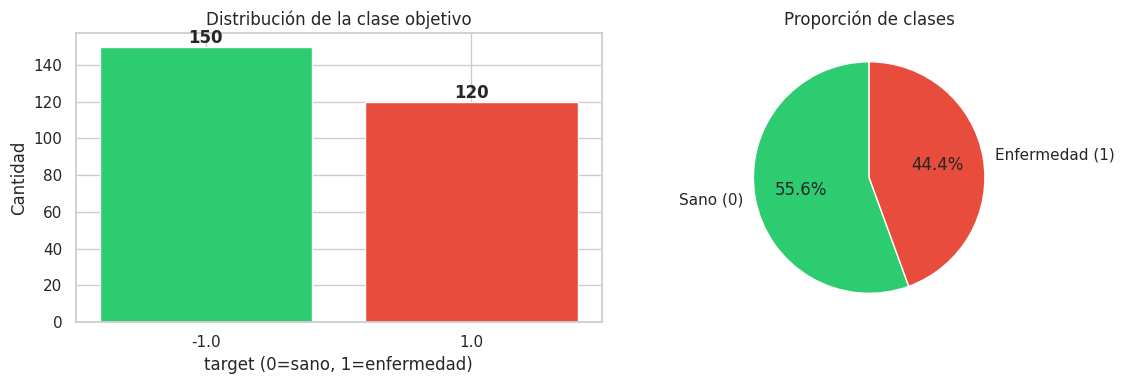

In [25]:
# 3.3  Distribución de la variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Conteo
target_counts = df['target'].value_counts()
axes[0].bar(target_counts.index.astype(str), target_counts.values,
            color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribución de la clase objetivo')
axes[0].set_xlabel('target (0=sano, 1=enfermedad)')
axes[0].set_ylabel('Cantidad')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

# Proporción
axes[1].pie(target_counts.values, labels=['Sano (0)', 'Enfermedad (1)'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Proporción de clases')

plt.tight_layout()
plt.show()

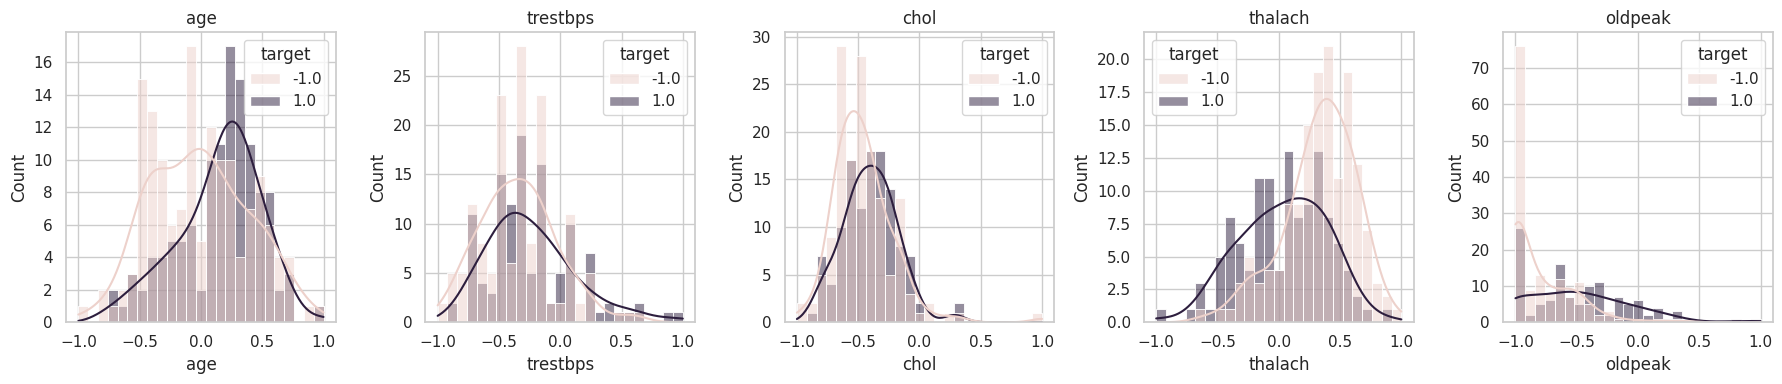

In [26]:
# 3.4  Distribución de variables numéricas clave
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(1, len(num_cols), figsize=(18, 4))
for ax, col in zip(axes, num_cols):
    sns.histplot(data=df, x=col, hue='target', kde=True, ax=ax, bins=25)
    ax.set_title(col)
plt.tight_layout()
plt.show()

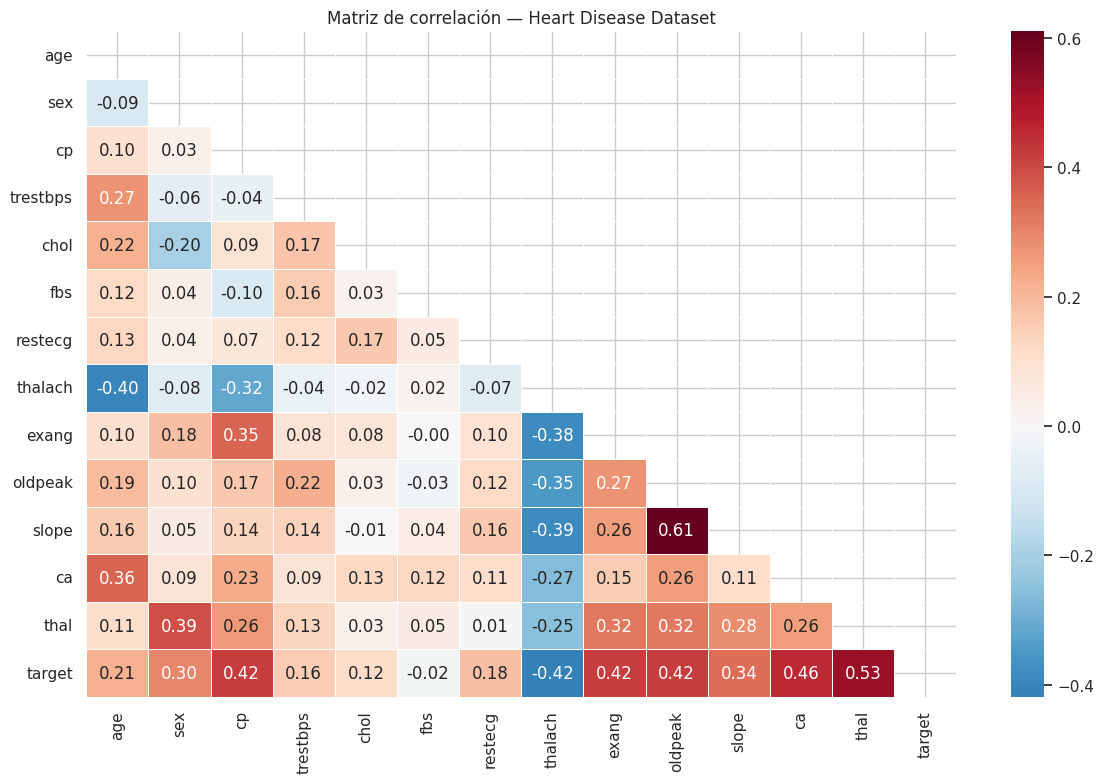

In [27]:
# 3.5  Matriz de correlación
plt.figure(figsize=(12, 8))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5)
plt.title('Matriz de correlación — Heart Disease Dataset')
plt.tight_layout()
plt.show()

---
## 4. Etapa 3 — Preparación de datos para el modelado

In [28]:
# 4.1  Separación de features y target
X = df.drop(columns='target')
y = df['target']

print(f'Features: {X.shape}')   # (n_samples, n_features)
print(f'Target:   {y.shape}')   # (n_samples,)

Features: (270, 13)
Target:   (270,)


In [29]:
# 4.2  División train / test (80-20, estratificado)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]} muestras')
print(f'Test:  {X_test.shape[0]} muestras')
print(f'\nProporción target en train:\n{y_train.value_counts(normalize=True).round(3)}')
print(f'\nProporción target en test:\n{y_test.value_counts(normalize=True).round(3)}')

Train: 216 muestras
Test:  54 muestras

Proporción target en train:
target
-1.0    0.556
 1.0    0.444
Name: proportion, dtype: float64

Proporción target en test:
target
-1.0    0.556
 1.0    0.444
Name: proportion, dtype: float64


---
## 5. Etapa 4 — Entrenamiento de modelos
Entrenamos tres modelos base mediante **pipelines** de Scikit-learn para garantizar un flujo reproducible.

In [30]:
# 5.1  Definición de pipelines
pipelines = {
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'DecisionTree': Pipeline([
        ('clf', DecisionTreeClassifier(max_depth=5, random_state=42))
    ]),
    'RandomForest': Pipeline([
        ('clf', RandomForestClassifier(n_estimators=200, max_depth=7, random_state=42))
    ])
}

# 5.2  Entrenamiento y validación cruzada (5-fold)
results = {}
for name, pipe in pipelines.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='accuracy')
    results[name] = scores
    print(f'{name:25s}  Accuracy CV: {scores.mean():.4f} ± {scores.std():.4f}')

LogisticRegression         Accuracy CV: 0.8288 ± 0.0682
DecisionTree               Accuracy CV: 0.7637 ± 0.0350
RandomForest               Accuracy CV: 0.8148 ± 0.0390


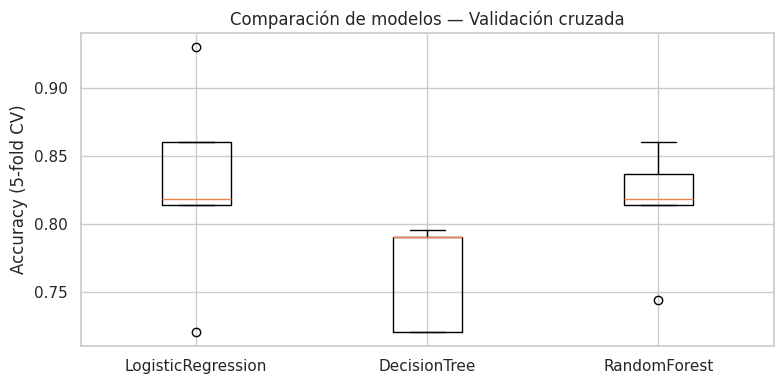

In [31]:
# 5.3  Comparación visual de modelos
fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(results.values(), tick_labels=results.keys())
ax.set_ylabel('Accuracy (5-fold CV)')
ax.set_title('Comparación de modelos — Validación cruzada')
plt.tight_layout()
plt.show()

---
## 6. Etapa 5 — Evaluación del mejor modelo

In [32]:
# 6.1  Seleccionar el mejor modelo según CV y entrenar con todo el train set
best_name = max(results, key=lambda k: results[k].mean())
best_pipeline = pipelines[best_name]
best_pipeline.fit(X_train, y_train)

y_pred = best_pipeline.predict(X_test)

print(f'Mejor modelo: {best_name}')
print(f'Accuracy en test: {best_pipeline.score(X_test, y_test):.4f}')
print('\n' + '='*60)
print('CLASSIFICATION REPORT')
print('='*60)
print(classification_report(y_test, y_pred, target_names=['Sano', 'Enfermedad']))

Mejor modelo: LogisticRegression
Accuracy en test: 0.8519

CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Sano       0.92      0.80      0.86        30
  Enfermedad       0.79      0.92      0.85        24

    accuracy                           0.85        54
   macro avg       0.85      0.86      0.85        54
weighted avg       0.86      0.85      0.85        54



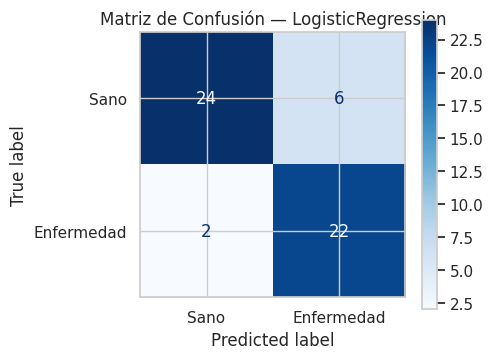

In [33]:
# 6.2  Matriz de confusión
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Sano', 'Enfermedad'],
    cmap='Blues', ax=ax
)
ax.set_title(f'Matriz de Confusión — {best_name}')
plt.tight_layout()
plt.show()

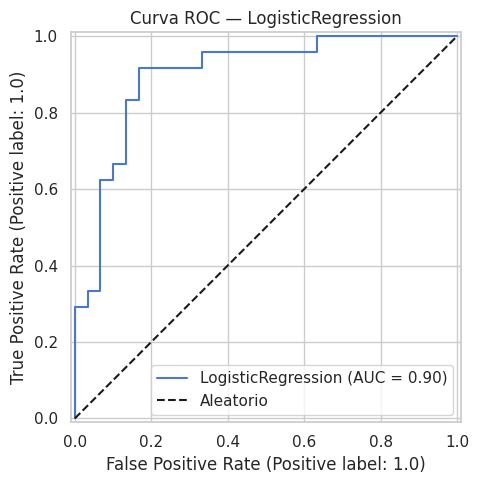

In [34]:
# 6.3  Curva ROC (solo si el modelo soporta predict_proba)
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_estimator(best_pipeline, X_test, y_test, ax=ax, name=best_name)
ax.plot([0, 1], [0, 1], 'k--', label='Aleatorio')
ax.set_title(f'Curva ROC — {best_name}')
ax.legend()
plt.tight_layout()
plt.show()

---
## 7. Etapa 6 — Serialización y despliegue conceptual
Guardamos el pipeline entrenado con `joblib` para simular la etapa de despliegue.

In [35]:
# 7.1  Guardar el modelo
MODEL_PATH = 'heart_disease_model.joblib'
joblib.dump(best_pipeline, MODEL_PATH)
print(f'Modelo guardado en: {MODEL_PATH}')

Modelo guardado en: heart_disease_model.joblib


In [36]:
# 7.2  Cargar y verificar el modelo serializado
loaded_model = joblib.load(MODEL_PATH)

# Verificación rápida: misma predicción con datos de test
assert np.array_equal(loaded_model.predict(X_test), y_pred), 'Error: predicciones no coinciden'
print('Verificación OK: el modelo cargado reproduce las predicciones.')

Verificación OK: el modelo cargado reproduce las predicciones.


In [37]:
# 7.3  Función de inferencia (simula un endpoint de predicción)
def predict_heart_disease(patient_data: dict) -> dict:
    """
    Recibe un diccionario con los features del paciente
    y retorna la predicción y la probabilidad.
    """
    model = joblib.load(MODEL_PATH)
    input_df = pd.DataFrame([patient_data])
    pred = model.predict(input_df)[0]
    proba = model.predict_proba(input_df)[0]
    return {
        'prediccion': 'Enfermedad cardíaca' if pred == 1 else 'Sano',
        'probabilidad_enfermedad': round(float(proba[1]), 4),
        'probabilidad_sano': round(float(proba[0]), 4)
    }

# Ejemplo de uso con un paciente ficticio
paciente_ejemplo = {
    'age': 55, 'sex': 1, 'cp': 2, 'trestbps': 140,
    'chol': 250, 'fbs': 0, 'restecg': 1, 'thalach': 150,
    'exang': 0, 'oldpeak': 1.5, 'slope': 1, 'ca': 0, 'thal': 2
}

resultado = predict_heart_disease(paciente_ejemplo)
print('\n--- Resultado de inferencia ---')
for k, v in resultado.items():
    print(f'  {k}: {v}')


--- Resultado de inferencia ---
  prediccion: Enfermedad cardíaca
  probabilidad_enfermedad: 1.0
  probabilidad_sano: 0.0


---
## 8. Resumen del ciclo de vida recorrido

| Etapa | Qué hicimos | Herramientas |
|---|---|---|
| **Recolección** | Descarga del dataset Heart Disease (UCI/OpenML) | `pandas`, URL pública |
| **Exploración** | Análisis de distribuciones, correlaciones, nulos | `seaborn`, `matplotlib` |
| **Preparación** | Limpieza, split estratificado 80/20 | `train_test_split` |
| **Entrenamiento** | 3 modelos con pipelines + validación cruzada 5-fold | `Pipeline`, `cross_val_score` |
| **Evaluación** | Accuracy, precision, recall, F1, ROC, matriz confusión | `classification_report`, `RocCurveDisplay` |
| **Despliegue** | Serialización con joblib + función de inferencia | `joblib` |

---
## 9. Ejercicios propuestos

### Ejercicio 1 — Experimentación con hiperparámetros
Utilice `GridSearchCV` o `RandomizedSearchCV` para optimizar los hiperparámetros del `RandomForestClassifier`. Compare el accuracy antes y después del tuning.

### Ejercicio 2 — Nuevo dataset, mismo pipeline
Descargue el dataset **Diabetes** de Scikit-learn (`sklearn.datasets.load_diabetes`) o el **Breast Cancer Wisconsin** (`sklearn.datasets.load_breast_cancer`) y replique el ciclo de vida completo aplicado en esta sesión.

### Ejercicio 3 — Registro de experimentos
Investigue la librería **MLflow** (`!pip install mlflow`) e implemente un registro básico de las métricas y parámetros de cada modelo entrenado. Documente los pasos realizados.

RESOLUCIÓN DE LA TAREA

Ejercicio 1 — Experimentación con hiperparámetros
Utilice GridSearchCV o RandomizedSearchCV para optimizar los hiperparámetros del RandomForestClassifier. Compare el accuracy antes y después del tuning.

---
## Ejercicio 1 — Experimentación con hiperparámetros
Optimizamos los hiperparámetros del `RandomForestClassifier` con `GridSearchCV` y comparamos el accuracy antes y después del tuning.

In [39]:
# 1. Baseline: RandomForest con los hiperparámetros por defecto (Parte 5)
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

baseline_rf = pipelines['RandomForest']
baseline_rf.fit(X_train, y_train)
y_pred_baseline = baseline_rf.predict(X_test)
acc_baseline = accuracy_score(y_test, y_pred_baseline)

print('='*60)
print('BASELINE — RandomForest sin tuning')
print('='*60)
print(f'Hiperparámetros: n_estimators=200, max_depth=7 (fijos, definidos manualmente)')
print(f'Accuracy en test: {acc_baseline:.4f}')
print('\nClassification report (baseline):')
print(classification_report(y_test, y_pred_baseline, target_names=['No bueno', 'Bueno']))

BASELINE — RandomForest sin tuning
Hiperparámetros: n_estimators=200, max_depth=7 (fijos, definidos manualmente)
Accuracy en test: 0.8333

Classification report (baseline):
              precision    recall  f1-score   support

    No bueno       0.86      0.83      0.85        30
       Bueno       0.80      0.83      0.82        24

    accuracy                           0.83        54
   macro avg       0.83      0.83      0.83        54
weighted avg       0.83      0.83      0.83        54



In [40]:
# 2. Definición de la grilla de búsqueda
# Usamos el prefijo 'clf__' porque RandomForestClassifier está dentro de un Pipeline
param_grid = {
    'clf__n_estimators': [100, 200, 300],
    'clf__max_depth': [5, 7, 10, None],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 2, 4],
    'clf__max_features': ['sqrt', 'log2']
}

print(f'Combinaciones totales en la grilla: '
      f'{len(param_grid["clf__n_estimators"]) * len(param_grid["clf__max_depth"]) * len(param_grid["clf__min_samples_split"]) * len(param_grid["clf__min_samples_leaf"]) * len(param_grid["clf__max_features"])}')

Combinaciones totales en la grilla: 216


In [41]:
# 3. Búsqueda de hiperparámetros con GridSearchCV (5-fold, igual que en la Etapa 4)
rf_pipeline = Pipeline([
    ('clf', RandomForestClassifier(random_state=42))
])

grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print('\n' + '='*60)
print('RESULTADOS DEL GRIDSEARCHCV')
print('='*60)
print(f'Mejores hiperparámetros: {grid_search.best_params_}')
print(f'Mejor accuracy (CV, train): {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 216 candidates, totalling 1080 fits

RESULTADOS DEL GRIDSEARCHCV
Mejores hiperparámetros: {'clf__max_depth': 5, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__n_estimators': 200}
Mejor accuracy (CV, train): 0.8425


In [42]:
# 4. Evaluar el modelo optimizado sobre el set de test
best_rf_tuned = grid_search.best_estimator_
y_pred_tuned = best_rf_tuned.predict(X_test)
acc_tuned = accuracy_score(y_test, y_pred_tuned)

print('='*60)
print('RANDOMFOREST OPTIMIZADO — Evaluación en test')
print('='*60)
print(f'Accuracy en test: {acc_tuned:.4f}')
print('\nClassification report (optimizado):')
print(classification_report(y_test, y_pred_tuned, target_names=['No bueno', 'Bueno']))

RANDOMFOREST OPTIMIZADO — Evaluación en test
Accuracy en test: 0.8333

Classification report (optimizado):
              precision    recall  f1-score   support

    No bueno       0.86      0.83      0.85        30
       Bueno       0.80      0.83      0.82        24

    accuracy                           0.83        54
   macro avg       0.83      0.83      0.83        54
weighted avg       0.83      0.83      0.83        54



                        Modelo  Accuracy
0      RandomForest (baseline)  0.833333
1  RandomForest (GridSearchCV)  0.833333


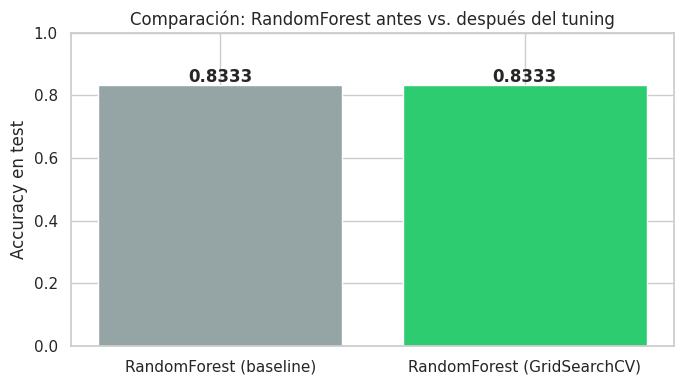


Mejora de accuracy: +0.0000 (+0.00 puntos porcentuales)


In [43]:
# 5. Comparación de accuracy antes y después del tuning
comparacion = pd.DataFrame({
    'Modelo': ['RandomForest (baseline)', 'RandomForest (GridSearchCV)'],
    'Accuracy': [acc_baseline, acc_tuned]
})
print(comparacion)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(comparacion['Modelo'], comparacion['Accuracy'],
              color=['#95a5a6', '#2ecc71'])
ax.set_ylabel('Accuracy en test')
ax.set_ylim(0, 1)
ax.set_title('Comparación: RandomForest antes vs. después del tuning')
for bar, val in zip(bars, comparacion['Accuracy']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.4f}',
            ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

mejora = acc_tuned - acc_baseline
print(f'\nMejora de accuracy: {mejora:+.4f} ({mejora*100:+.2f} puntos porcentuales)')

Ejercicio 2 — Nuevo dataset, mismo pipeline
Descargue el dataset Diabetes de Scikit-learn (sklearn.datasets.load_diabetes) o el Breast Cancer Wisconsin (sklearn.datasets.load_breast_cancer) y replique el ciclo de vida completo aplicado en esta sesión.

1. Configuración del entorno

In [3]:
# Librerías principales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)
import joblib

# Configuración visual
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print('Entorno configurado correctamente.')

Entorno configurado correctamente.


---
## 2. Etapa 1 — Recolección de datos
Cargamos el **Wine Quality dataset (Red Wine)** directamente desde el repositorio UCI Machine Learning a través de una URL pública (la misma fuente original en la que se basa el dataset de Kaggle "uciml/red-wine-quality-cortez-et-al-2009").

| Variable | Descripción |
|---|---|
| `fixed acidity` | Acidez fija (g/dm³ de ácido tartárico) |
| `volatile acidity` | Acidez volátil (g/dm³ de ácido acético) |
| `citric acid` | Ácido cítrico (g/dm³) |
| `residual sugar` | Azúcar residual (g/dm³) |
| `chlorides` | Cloruros (g/dm³ de cloruro de sodio) |
| `free sulfur dioxide` | Dióxido de azufre libre (mg/dm³) |
| `total sulfur dioxide` | Dióxido de azufre total (mg/dm³) |
| `density` | Densidad (g/cm³) |
| `pH` | Nivel de acidez/alcalinidad |
| `sulphates` | Sulfatos (g/dm³ de sulfato de potasio) |
| `alcohol` | Grado alcohólico (% vol.) |
| `quality` | Calidad del vino, puntuación de 0 a 10 (variable objetivo) |

In [4]:
# Fuente pública: repositorio UCI Machine Learning (mismo dataset base que en Kaggle)
URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'

# Intentamos cargar desde la URL oficial de UCI; si falla, usamos un mirror en GitHub
try:
    df = pd.read_csv(URL, sep=';')
    print(f'Dataset cargado desde UCI — {df.shape[0]} registros, {df.shape[1]} columnas')
except Exception as e:
    print(f'Error al cargar desde UCI: {e}')
    print('Intentando cargar desde mirror de GitHub como alternativa...')
    URL_MIRROR = 'https://raw.githubusercontent.com/shrikant-temburwar/Wine-Quality-Dataset/refs/heads/master/winequality-red.csv'
    try:
        df = pd.read_csv(URL_MIRROR, sep=';')
        print(f'Dataset cargado desde mirror de GitHub — {df.shape[0]} registros, {df.shape[1]} columnas')
    except Exception as mirror_e:
        print(f'Error al cargar desde el mirror: {mirror_e}')
        print('No se pudo cargar el dataset desde ninguna fuente.')
        raise  # Re-lanzamos la excepción si ambos métodos fallan

df.head()

Dataset cargado desde UCI — 1599 registros, 12 columnas


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


---
## 3. Etapa 2 — Exploración y preparación de datos

In [5]:
# 3.1  Información general del dataset
print('='*60)
print('INFORMACIÓN DEL DATASET')
print('='*60)
df.info()
print('\n')
df.describe().round(2)

INFORMACIÓN DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB




,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00
mean,8.32,0.53,0.27,2.54,0.09,15.87,46.47,1.00,3.31,0.66,10.42,5.64
std,1.74,0.18,0.19,1.41,0.05,10.46,32.90,0.00,0.15,0.17,1.07,0.81
min,4.60,0.12,0.00,0.90,0.01,1.00,6.00,0.99,2.74,0.33,8.40,3.00
25%,7.10,0.39,0.09,1.90,0.07,7.00,22.00,1.00,3.21,0.55,9.50,5.00
50%,7.90,0.52,0.26,2.20,0.08,14.00,38.00,1.00,3.31,0.62,10.20,6.00
75%,9.20,0.64,0.42,2.60,0.09,21.00,62.00,1.00,3.40,0.73,11.10,6.00
max,15.90,1.58,1.00,15.50,0.61,72.00,289.00,1.00,4.01,2.00,14.90,8.00


In [6]:
# 3.2  Verificación de valores nulos y duplicados
print('Valores nulos por columna:')
print(df.isnull().sum())
print(f'\nRegistros duplicados: {df.duplicated().sum()}')

# Eliminar duplicados si existen
df = df.drop_duplicates().reset_index(drop=True)
print(f'Registros después de limpieza: {df.shape[0]}')

Valores nulos por columna:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Registros duplicados: 240
Registros después de limpieza: 1359


/tmp/ipykernel_5236/2363321137.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='quality', data=df, palette='viridis')


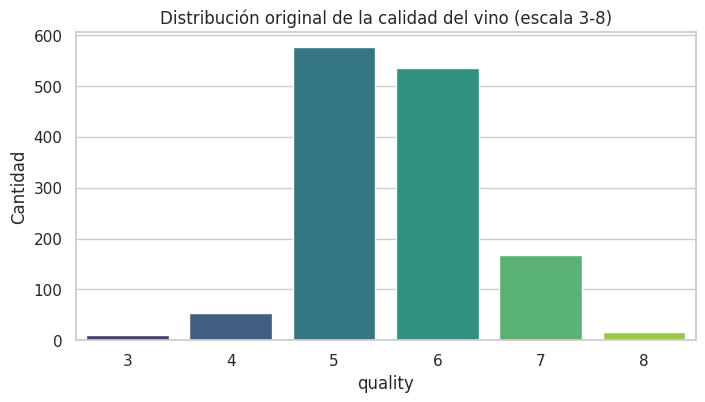

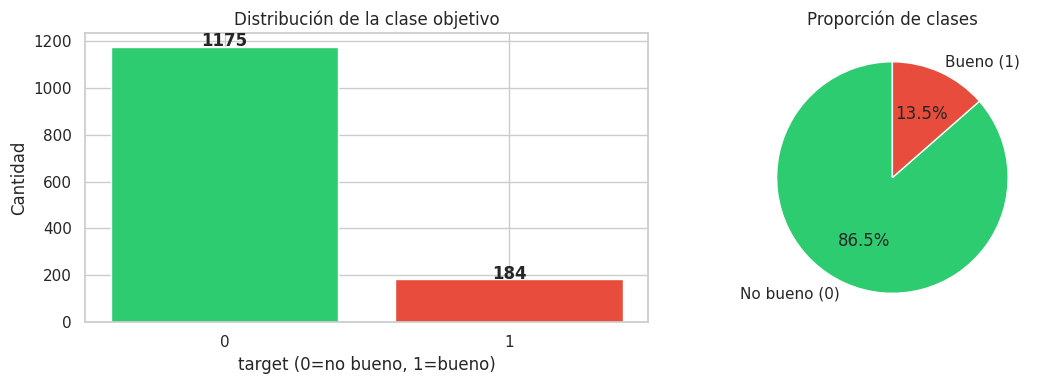

In [7]:
# 3.3  Distribución original de 'quality' (variable ordinal, 3-8)
plt.figure(figsize=(8, 4))
sns.countplot(x='quality', data=df, palette='viridis')
plt.title('Distribución original de la calidad del vino (escala 3-8)')
plt.xlabel('quality')
plt.ylabel('Cantidad')
plt.show()

# 'quality' está muy desbalanceada en los extremos (casi no hay vinos con
# nota 3, 4 u 8). Igual que el ingeniero trabajó con un target binario
# (0=sano, 1=enfermedad), convertimos el problema en clasificación BINARIA:
# vino "bueno" (quality >= 7) vs "no bueno" (quality < 7)
df['target'] = (df['quality'] >= 7).astype(int)
df = df.drop(columns='quality')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Conteo
target_counts = df['target'].value_counts()
axes[0].bar(target_counts.index.astype(str), target_counts.values,
            color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribución de la clase objetivo')
axes[0].set_xlabel('target (0=no bueno, 1=bueno)')
axes[0].set_ylabel('Cantidad')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

# Proporción
axes[1].pie(target_counts.values, labels=['No bueno (0)', 'Bueno (1)'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Proporción de clases')

plt.tight_layout()
plt.show()

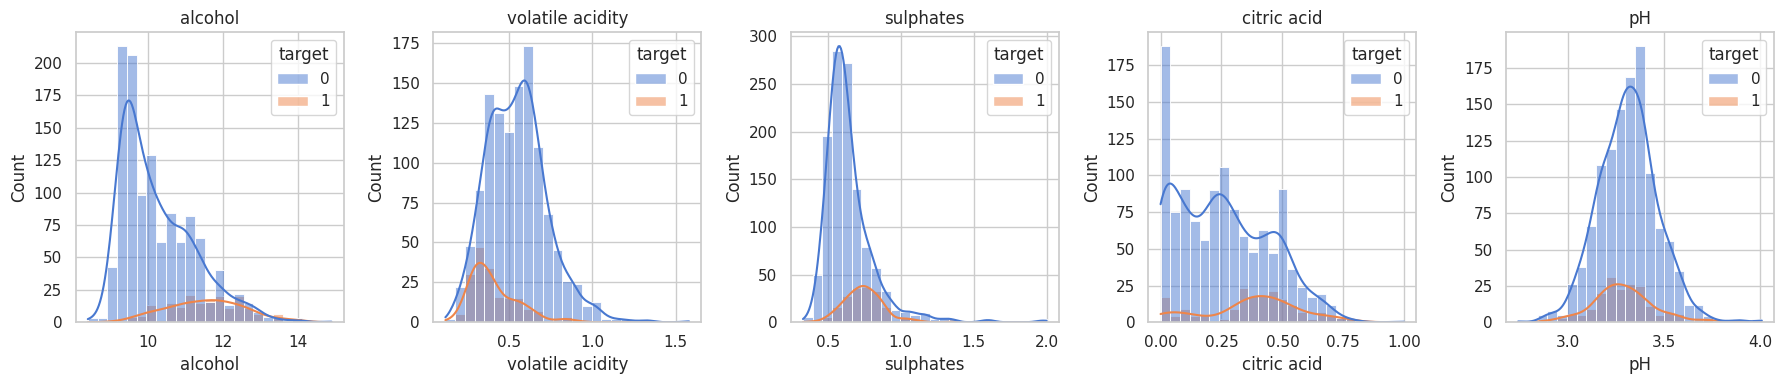

In [8]:
# 3.4  Distribución de variables numéricas clave
num_cols = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid', 'pH']

fig, axes = plt.subplots(1, len(num_cols), figsize=(18, 4))
for ax, col in zip(axes, num_cols):
    sns.histplot(data=df, x=col, hue='target', kde=True, ax=ax, bins=25)
    ax.set_title(col)
plt.tight_layout()
plt.show()

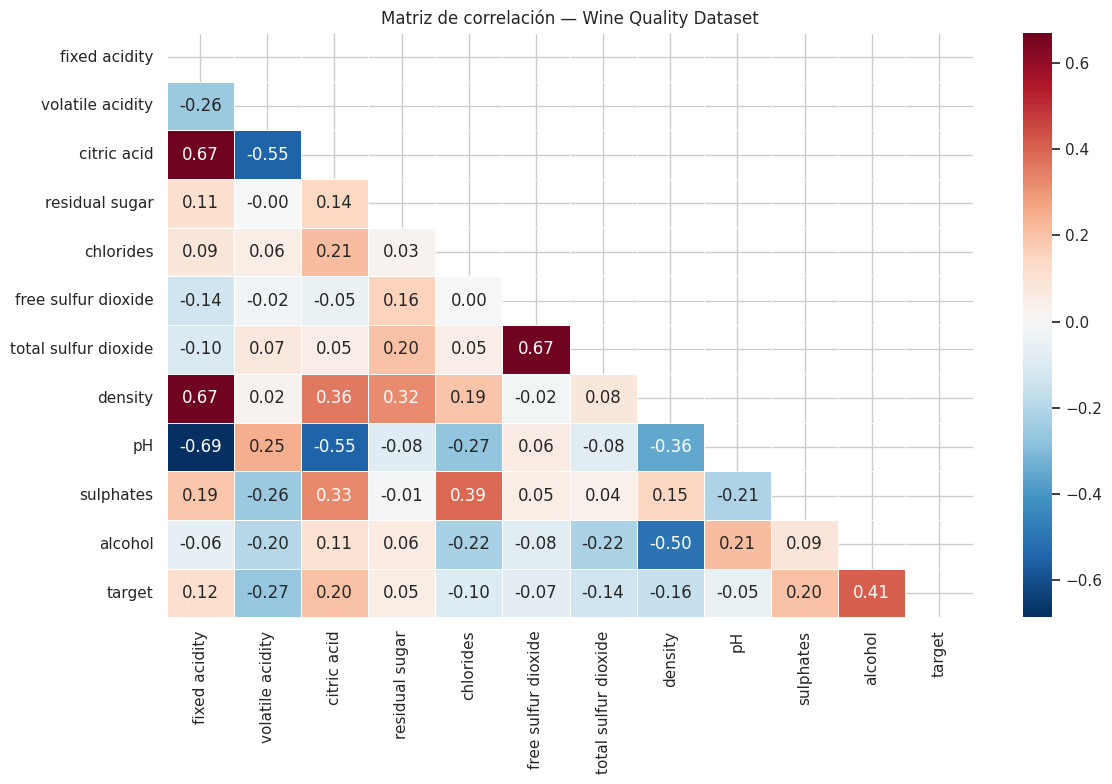

In [9]:
# 3.5  Matriz de correlación
plt.figure(figsize=(12, 8))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5)
plt.title('Matriz de correlación — Wine Quality Dataset')
plt.tight_layout()
plt.show()

---
## 4. Etapa 3 — Preparación de datos para el modelado

In [10]:
# 4.1  Separación de features y target
X = df.drop(columns='target')
y = df['target']

print(f'Features: {X.shape}')   # (n_samples, n_features)
print(f'Target:   {y.shape}')   # (n_samples,)

Features: (1359, 11)
Target:   (1359,)


In [11]:
# 4.2  División train / test (80-20, estratificado)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]} muestras')
print(f'Test:  {X_test.shape[0]} muestras')
print(f'\nProporción target en train:\n{y_train.value_counts(normalize=True).round(3)}')
print(f'\nProporción target en test:\n{y_test.value_counts(normalize=True).round(3)}')

Train: 1087 muestras
Test:  272 muestras

Proporción target en train:
target
0    0.865
1    0.135
Name: proportion, dtype: float64

Proporción target en test:
target
0    0.864
1    0.136
Name: proportion, dtype: float64


---
## 5. Etapa 4 — Entrenamiento de modelos
Entrenamos tres modelos base mediante **pipelines** de Scikit-learn para garantizar un flujo reproducible.

In [12]:
# 5.1  Definición de pipelines
pipelines = {
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'DecisionTree': Pipeline([
        ('clf', DecisionTreeClassifier(max_depth=5, random_state=42))
    ]),
    'RandomForest': Pipeline([
        ('clf', RandomForestClassifier(n_estimators=200, max_depth=7, random_state=42))
    ])
}

# 5.2  Entrenamiento y validación cruzada (5-fold)
results = {}
for name, pipe in pipelines.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='accuracy')
    results[name] = scores
    print(f'{name:25s}  Accuracy CV: {scores.mean():.4f} ± {scores.std():.4f}')

LogisticRegression         Accuracy CV: 0.8768 ± 0.0188
DecisionTree               Accuracy CV: 0.8639 ± 0.0230
RandomForest               Accuracy CV: 0.8786 ± 0.0156


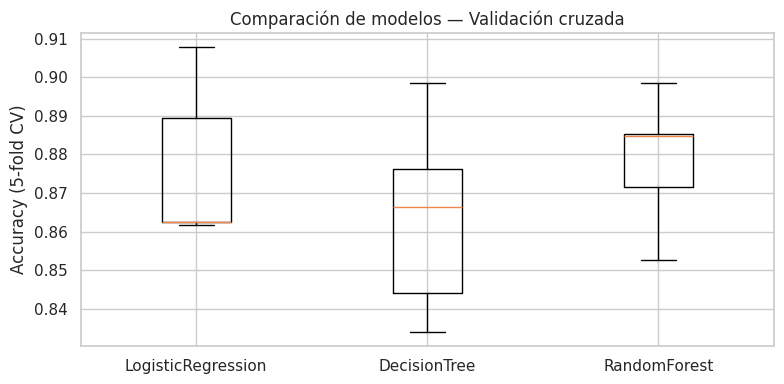

In [13]:
# 5.3  Comparación visual de modelos
fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(results.values(), tick_labels=results.keys())
ax.set_ylabel('Accuracy (5-fold CV)')
ax.set_title('Comparación de modelos — Validación cruzada')
plt.tight_layout()
plt.show()

---
*Ingeniería del Conocimiento (ISO56B) — UNCP — 2026-II*

---
## 6. Etapa 5 — Evaluación del mejor modelo

In [14]:
# 6.1  Seleccionar el mejor modelo según CV y entrenar con todo el train set
best_name = max(results, key=lambda k: results[k].mean())
best_pipeline = pipelines[best_name]
best_pipeline.fit(X_train, y_train)

y_pred = best_pipeline.predict(X_test)

print(f'Mejor modelo: {best_name}')
print(f'Accuracy en test: {best_pipeline.score(X_test, y_test):.4f}')
print('\n' + '='*60)
print('CLASSIFICATION REPORT')
print('='*60)
print(classification_report(y_test, y_pred, target_names=['No bueno', 'Bueno']))

Mejor modelo: RandomForest
Accuracy en test: 0.8897

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    No bueno       0.90      0.98      0.94       235
       Bueno       0.71      0.32      0.44        37

    accuracy                           0.89       272
   macro avg       0.80      0.65      0.69       272
weighted avg       0.88      0.89      0.87       272



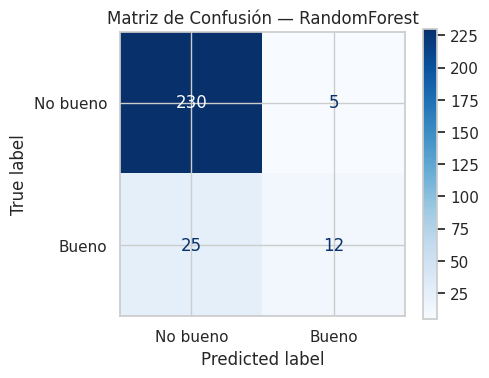

In [15]:
# 6.2  Matriz de confusión
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['No bueno', 'Bueno'],
    cmap='Blues', ax=ax
)
ax.set_title(f'Matriz de Confusión — {best_name}')
plt.tight_layout()
plt.show()

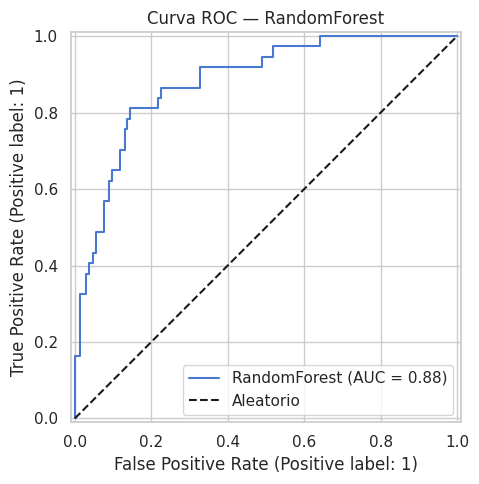

In [16]:
# 6.3  Curva ROC (solo si el modelo soporta predict_proba)
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_estimator(best_pipeline, X_test, y_test, ax=ax, name=best_name)
ax.plot([0, 1], [0, 1], 'k--', label='Aleatorio')
ax.set_title(f'Curva ROC — {best_name}')
ax.legend()
plt.tight_layout()
plt.show()

---
## 7. Etapa 6 — Serialización y despliegue conceptual
Guardamos el pipeline entrenado con `joblib` para simular la etapa de despliegue.

In [17]:
# 7.1  Guardar el modelo
MODEL_PATH = 'wine_quality_model.joblib'
joblib.dump(best_pipeline, MODEL_PATH)
print(f'Modelo guardado en: {MODEL_PATH}')

Modelo guardado en: wine_quality_model.joblib


In [18]:
# 7.2  Cargar y verificar el modelo serializado
loaded_model = joblib.load(MODEL_PATH)

# Verificación rápida: misma predicción con datos de test
assert np.array_equal(loaded_model.predict(X_test), y_pred), 'Error: predicciones no coinciden'
print('Verificación OK: el modelo cargado reproduce las predicciones.')

Verificación OK: el modelo cargado reproduce las predicciones.


In [19]:
# 7.3  Función de inferencia (simula un endpoint de predicción)
def predict_wine_quality(wine_data: dict) -> dict:
    """
    Recibe un diccionario con las propiedades fisicoquímicas del vino
    y retorna la predicción y la probabilidad.
    """
    model = joblib.load(MODEL_PATH)
    input_df = pd.DataFrame([wine_data])
    pred = model.predict(input_df)[0]
    proba = model.predict_proba(input_df)[0]
    return {
        'prediccion': 'Vino bueno' if pred == 1 else 'Vino no bueno',
        'probabilidad_bueno': round(float(proba[1]), 4),
        'probabilidad_no_bueno': round(float(proba[0]), 4)
    }

# Ejemplo de uso con una muestra de vino ficticia
vino_ejemplo = {
    'fixed acidity': 7.9, 'volatile acidity': 0.35, 'citric acid': 0.46,
    'residual sugar': 2.3, 'chlorides': 0.073, 'free sulfur dioxide': 12,
    'total sulfur dioxide': 30, 'density': 0.9968, 'pH': 3.2,
    'sulphates': 0.85, 'alcohol': 12.0
}

resultado = predict_wine_quality(vino_ejemplo)
print('\n--- Resultado de inferencia ---')
for k, v in resultado.items():
    print(f'  {k}: {v}')


--- Resultado de inferencia ---
  prediccion: Vino bueno
  probabilidad_bueno: 0.5965
  probabilidad_no_bueno: 0.4035


Ejercicio 3 — Registro de experimentos
Investigue la librería MLflow (!pip install mlflow) e implemente un registro básico de las métricas y parámetros de cada modelo entrenado. Documente los pasos realizados.

In [50]:
# ============================================================
# EJERCICIO 3 — Registro de experimentos con MLflow
# Dataset: Wine Quality (Red) — Kaggle uciml/red-wine-quality-cortez-et-al-2009
# ============================================================
# Pasos realizados:
#  1. Se instala/importa MLflow y se define un experimento.
#  2. Se registran en MLflow los parámetros e hiperparámetros de cada uno
#     de los 3 modelos entrenados en el Ejercicio 2 (LogisticRegression,
#     DecisionTree, RandomForest), junto con su accuracy de validación
#     cruzada. Se valida primero que esos modelos correspondan al dataset
#     Wine Quality (y no a otro ejercicio previo con variables en memoria).
#     Se usa serialization_format="cloudpickle" para evitar el bloqueo de
#     skops con la estructura interna de los árboles de decisión.
#  3. Se recupera el mejor modelo YA ENTRENADO (sin reentrenar), validando
#     que sus columnas de entrada coincidan con las del Wine Quality,
#     tanto si viene de memoria (best_pipeline) como del archivo
#     wine_quality_model.joblib.
#  4. Se construye una interfaz interactiva por consola: el usuario
#     ingresa cada variable fisicoquímica del vino, con validación de
#     tipo y de rango; si el dato es inválido, se vuelve a solicitar.
#  5. Cada predicción realizada por el usuario se registra también como
#     un run de MLflow, dejando trazabilidad de entrenamiento e inferencia.
# ============================================================

!pip install mlflow -q

import os
import joblib
import pandas as pd
import mlflow
import mlflow.sklearn

# ------------------------------------------------------------
# 1. Configuración del experimento en MLflow
# ------------------------------------------------------------
mlflow.set_experiment("Wine_Quality_UNCP_ISO56B")

# ------------------------------------------------------------
# Variables/rangos del Wine Quality (se definen primero porque
# también se usan para VALIDAR que el modelo en memoria/disco
# sea realmente el del vino, y no el de otro ejercicio previo)
# ------------------------------------------------------------
FEATURES_INFO = {
    'fixed acidity':        ('Acidez fija',            'g/dm³',  4.0,  16.0),
    'volatile acidity':     ('Acidez volátil',         'g/dm³',  0.10,  1.60),
    'citric acid':          ('Ácido cítrico',          'g/dm³',  0.00,  1.00),
    'residual sugar':       ('Azúcar residual',        'g/dm³',  0.50, 16.00),
    'chlorides':             ('Cloruros',               'g/dm³',  0.010, 0.650),
    'free sulfur dioxide':  ('Dióxido de azufre libre','mg/dm³',  1.0,  75.0),
    'total sulfur dioxide': ('Dióxido de azufre total','mg/dm³',  5.0, 300.0),
    'density':               ('Densidad',               'g/cm³',  0.985, 1.005),
    'pH':                    ('pH',                     '',       2.70,  4.10),
    'sulphates':             ('Sulfatos',               'g/dm³',  0.30,  2.10),
    'alcohol':               ('Grado alcohólico',       '% vol.', 8.00, 15.00),
}
COLUMNAS_WINE = list(FEATURES_INFO.keys())

def es_modelo_wine(modelo):
    """Verifica que el modelo/pipeline haya sido entrenado con las
    columnas del Wine Quality (y no con las de otro dataset, como
    el Heart Disease del ejemplo del ingeniero)."""
    columnas = getattr(modelo, 'feature_names_in_', None)
    if columnas is None:
        return False
    return list(columnas) == COLUMNAS_WINE

# ------------------------------------------------------------
# 2. Registro de los modelos entrenados en el Ejercicio 2
#    (parámetros + métricas de validación cruzada)
# ------------------------------------------------------------
if 'pipelines' in globals() and 'results' in globals() and all(es_modelo_wine(p) for p in pipelines.values()):
    print("Registrando en MLflow los modelos del Ejercicio 2 (Wine Quality)...\n")
    for nombre, pipe in pipelines.items():
        with mlflow.start_run(run_name=f"entrenamiento_{nombre}"):
            mlflow.set_tag("etapa", "entrenamiento")
            mlflow.set_tag("dataset", "Wine Quality (Red) - Kaggle uciml")

            clf = pipe.named_steps['clf']
            mlflow.log_params(clf.get_params())

            cv_scores = results[nombre]
            mlflow.log_metric("cv_accuracy_mean", float(cv_scores.mean()))
            mlflow.log_metric("cv_accuracy_std", float(cv_scores.std()))

            if 'best_name' in globals() and nombre == best_name and 'X_test' in globals() and 'y_test' in globals():
                mlflow.log_metric("test_accuracy", float(pipe.score(X_test, y_test)))
                mlflow.set_tag("mejor_modelo", "si")

            mlflow.sklearn.log_model(
                pipe,
                artifact_path="modelo",
                serialization_format="cloudpickle",
            )

        print(f"  ✔ Registrado: {nombre}  (CV accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f})")
    print("\nRegistro de entrenamiento completado.\n")
else:
    print("⚠️ Las variables 'pipelines'/'results' en memoria no corresponden al Wine Quality")
    print("   (o no existen). Se omite el registro de entrenamiento y se continúa con el")
    print("   modelo ya guardado en 'wine_quality_model.joblib'.\n")

# ------------------------------------------------------------
# 3. Recuperar el modelo YA ENTRENADO (sin reentrenar), validando
#    que sea efectivamente el del Wine Quality
# ------------------------------------------------------------
RUTA_MODELO_WINE = 'wine_quality_model.joblib'
modelo_final = None
nombre_modelo_final = None

if 'best_pipeline' in globals() and es_modelo_wine(best_pipeline):
    modelo_final = best_pipeline
    nombre_modelo_final = best_name if 'best_name' in globals() else type(modelo_final.named_steps['clf']).__name__
elif os.path.exists(RUTA_MODELO_WINE):
    candidato = joblib.load(RUTA_MODELO_WINE)
    if es_modelo_wine(candidato):
        modelo_final = candidato
        nombre_modelo_final = type(modelo_final.named_steps['clf']).__name__

if modelo_final is None:
    raise RuntimeError(
        "No se encontró un modelo válido del Wine Quality (Ejercicio 2). "
        "Ve a las celdas del Ejercicio 2 (sección 'Wine Quality, mismo pipeline') "
        "y ejecútalas TODAS en esta misma sesión —desde la carga del dataset hasta "
        "el guardado con joblib.dump()— y luego vuelve a correr esta celda."
    )

print(f"Modelo cargado para inferencia: {nombre_modelo_final} (Wine Quality, no se reentrena).\n")

# ------------------------------------------------------------
# 4. Interfaz interactiva: solicitud validada de datos del vino
# ------------------------------------------------------------
def solicitar_valor(etiqueta, unidad, vmin, vmax):
    """Pide un valor numérico al usuario, validando tipo y rango.
    Reintenta indefinidamente hasta recibir un dato correcto."""
    while True:
        texto_unidad = f" ({unidad})" if unidad else ""
        entrada = input(f"  {etiqueta}{texto_unidad} [rango válido: {vmin} - {vmax}]: ").strip()
        entrada = entrada.replace(',', '.')
        try:
            valor = float(entrada)
        except ValueError:
            print("  ⚠️  Dato inválido: debe ingresar un número (ej. 7.4). Intente nuevamente.")
            continue
        if valor < vmin or valor > vmax:
            print(f"  ⚠️  Fuera de rango: el valor debe estar entre {vmin} y {vmax}. Intente nuevamente.")
            continue
        return valor

def realizar_prediccion_interactiva(modelo, nombre_modelo):
    print("\nIngrese las características fisicoquímicas del vino:")
    datos_vino = {}
    for columna, (etiqueta, unidad, vmin, vmax) in FEATURES_INFO.items():
        datos_vino[columna] = solicitar_valor(etiqueta, unidad, vmin, vmax)

    input_df = pd.DataFrame([datos_vino])[COLUMNAS_WINE]  # aseguramos el orden correcto
    pred = modelo.predict(input_df)[0]
    proba = modelo.predict_proba(input_df)[0]

    resultado = {
        'prediccion': 'Vino bueno' if pred == 1 else 'Vino no bueno',
        'probabilidad_bueno': round(float(proba[1]), 4),
        'probabilidad_no_bueno': round(float(proba[0]), 4),
    }

    with mlflow.start_run(run_name=f"inferencia_{nombre_modelo}"):
        mlflow.set_tag("etapa", "inferencia_interactiva")
        mlflow.log_params(datos_vino)
        mlflow.log_param("modelo_usado", nombre_modelo)
        mlflow.log_param("prediccion", resultado['prediccion'])
        mlflow.log_metric("probabilidad_bueno", resultado['probabilidad_bueno'])
        mlflow.log_metric("probabilidad_no_bueno", resultado['probabilidad_no_bueno'])

    return resultado

# ------------------------------------------------------------
# 5. Menú interactivo principal
# ------------------------------------------------------------
def menu_interactivo():
    print("=" * 60)
    print(" SISTEMA INTERACTIVO DE PREDICCIÓN — WINE QUALITY")
    print(f" Modelo en uso: {nombre_modelo_final}")
    print("=" * 60)

    while True:
        print("\nOpciones disponibles:")
        print("  1) Realizar una nueva predicción")
        print("  2) Salir")
        opcion = input("Seleccione una opción (1-2): ").strip()

        if opcion == '1':
            resultado = realizar_prediccion_interactiva(modelo_final, nombre_modelo_final)
            print("\n--- Resultado de la predicción ---")
            for clave, valor in resultado.items():
                print(f"  {clave}: {valor}")
        elif opcion == '2':
            print("\nSaliendo del sistema. ¡Gracias!")
            break
        else:
            print("⚠️  Opción inválida. Ingrese 1 o 2.")

menu_interactivo()

print("\nPara visualizar todos los experimentos y runs registrados, ejecute en una terminal:")
print("  mlflow ui")
print("y abra el enlace que le indique (por defecto http://127.0.0.1:5000)")

⚠️ Las variables 'pipelines'/'results' en memoria no corresponden al Wine Quality
   (o no existen). Se omite el registro de entrenamiento y se continúa con el
   modelo ya guardado en 'wine_quality_model.joblib'.

Modelo cargado para inferencia: RandomForestClassifier (Wine Quality, no se reentrena).

 SISTEMA INTERACTIVO DE PREDICCIÓN — WINE QUALITY
 Modelo en uso: RandomForestClassifier

Opciones disponibles:
  1) Realizar una nueva predicción
  2) Salir
Seleccione una opción (1-2): 1

Ingrese las características fisicoquímicas del vino:
  Acidez fija (g/dm³) [rango válido: 4.0 - 16.0]: 4
  Acidez volátil (g/dm³) [rango válido: 0.1 - 1.6]: 0.1
  Ácido cítrico (g/dm³) [rango válido: 0.0 - 1.0]: 1
  Azúcar residual (g/dm³) [rango válido: 0.5 - 16.0]: 0.5
  Cloruros (g/dm³) [rango válido: 0.01 - 0.65]: 0.15
  Dióxido de azufre libre (mg/dm³) [rango válido: 1.0 - 75.0]: 1
  Dióxido de azufre total (mg/dm³) [rango válido: 5.0 - 300.0]: 8
  Densidad (g/cm³) [rango válido: 0.985 - 1.005]: 